# EGU26 Hydrological GNN — Training Notebook
**목적**: 미호천 유역 Chl-a 예측 (Transformer + SAGEConv 시공간 GNN)
**실행 환경**: Google Colab (GPU 런타임 권장)

---
## 실행 전 체크리스트
1. `런타임 → 런타임 유형 변경 → GPU` 설정
2. 아래의 `git clone` 셀을 실행하여 깃허브에서 최신 코드를 받아옵니다.


## 1. 환경 세팅

In [70]:
# 깃허브에서 최신 코드 강제 동기화 (기존 캐시 충돌 방지)
import os
import sys
import shutil

if os.path.exists('EGU26-SWAT-GNN'):
    # Colab 내부에 수정된 파일이 있어 git pull이 막히는 것을 방지하기 위해 폴더 통째로 삭제
    shutil.rmtree('EGU26-SWAT-GNN')
    
!git clone https://github.com/kona0107/EGU26-SWAT-GNN.git

# 모듈 경로 추가 및 데이터 경로 확인
MODULE_PATH = os.path.abspath('EGU26-SWAT-GNN/script/src/gnn_project')
if MODULE_PATH not in sys.path:
    sys.path.insert(0, MODULE_PATH)
    
DATA_PATH    = os.path.abspath('EGU26-SWAT-GNN/script/data')
OUTLET_CSV   = os.path.join(DATA_PATH, 'outlet_lag_pcp.csv')
UPSTREAM_CSV = os.path.join(DATA_PATH, 'upstream_lag_pcp.csv')

print('Outlet CSV:', os.path.exists(OUTLET_CSV))
print('Upstream CSV:', os.path.exists(UPSTREAM_CSV))


Cloning into 'EGU26-SWAT-GNN'...
remote: Enumerating objects: 190, done.
remote: Counting objects: 100% (190/190), done.
remote: Compressing objects: 100% (103/103), done.
remote: Total 190 (delta 64), reused 164 (delta 44), pack-reused 0 (from 0)
Receiving objects: 100% (190/190), 19.31 MiB | 45.05 MiB/s, done.
Resolving deltas: 100% (64/64), done.
/content/EGU26-SWAT-GNN/EGU26-SWAT-GNN/EGU26-SWAT-GNN/EGU26-SWAT-GNN/EGU26-SWAT-GNN/EGU26-SWAT-GNN/EGU26-SWAT-GNN
From https://github.com/kona0107/EGU26-SWAT-GNN
 * branch            main       -> FETCH_HEAD
Already up to date.


In [71]:
# 의존 패키지 설치 (PyTorch Geometric)
import torch
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available : {torch.cuda.is_available()}')

!pip install torch_geometric -q
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv \
    -f https://data.pyg.org/whl/torch-$(python -c "import torch; print(torch.__version__)").html -q

PyTorch version: 2.10.0+cpu
CUDA available : False


In [72]:
import sys
import os

# ⚙️ 경로 설정 (git clone 한 위치 기준)
PROJECT_ROOT = '.'
MODULE_PATH  = os.path.join(PROJECT_ROOT, 'script/src/gnn_project')
DATA_PATH    = os.path.join(PROJECT_ROOT, 'script/data')

OUTLET_CSV   = os.path.join(DATA_PATH, 'outlet_lag_pcp.csv')
UPSTREAM_CSV = os.path.join(DATA_PATH, 'upstream_lag_pcp.csv')

sys.path.insert(0, MODULE_PATH)
print('Module path:', MODULE_PATH)
print('Outlet  CSV:', os.path.exists(OUTLET_CSV))
print('Upstream CSV:', os.path.exists(UPSTREAM_CSV))


Module path: ./script/src/gnn_project
Outlet  CSV: True
Upstream CSV: True


In [73]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from data.dataset import (
    load_real_data, prepare_and_split_data,
    FEATURE_DIM, OUTLET_IDX, N_NODES
)
from models.temporal import TransformerBaseline
from models.st_gcn   import SpatioTemporalHybridGNN

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

Using device: cpu


## 2. 데이터 로딩 및 분할

In [74]:
# ── 하이퍼파라미터 ───────────────────────────
LOOKBACK    = 10   # 관측 윈도우 크기 (타임스텝 수)
TRAIN_RATIO = 0.7
VAL_RATIO   = 0.15
BATCH_SIZE  = 16
# ─────────────────────────────────────────────

raw_features, dates = load_real_data(OUTLET_CSV, UPSTREAM_CSV)
print(f'총 관측 날짜 수 (T) : {len(dates)}')
print(f'raw_features shape : {raw_features.shape}  → 기대: [T, 29, 10]')
print(f'날짜 범위           : {dates[0]}  ~  {dates[-1]}')

총 관측 날짜 수 (T) : 191
raw_features shape : (191, 29, 10)  → 기대: [T, 29, 10]
날짜 범위           : 2019-01-08 00:00:00  ~  2024-12-17 00:00:00


In [75]:
train_ds, val_ds, test_ds, scaler_out = prepare_and_split_data(
    raw_features,
    outlet_node_idx = OUTLET_IDX,
    lookback_window = LOOKBACK,
    train_ratio     = TRAIN_RATIO,
    val_ratio       = VAL_RATIO
)

print(f'Train / Val / Test 샘플 수: {len(train_ds)} / {len(val_ds)} / {len(test_ds)}')

# DataLoader
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# 배치 shape 확인
bx, by, bidx = next(iter(train_loader))
print(f'배치 X shape: {bx.shape}   (기대: [B, L, 29, 11])')
print(f'배치 y shape: {by.shape}   (기대: [B, 1])')

Train / Val / Test 샘플 수: 123 / 18 / 20
배치 X shape: torch.Size([16, 10, 29, 11])   (기대: [B, L, 29, 11])
배치 y shape: torch.Size([16, 1])   (기대: [B, 1])


## 3. Graph Edge 정의

In [76]:
# Upstream → Downstream 단방향 엣지
edges_list = [
    (20, 5), (5, 23), (21, 24), (22, 24), (24, 23), (23, 25), (4, 25), (19, 25),
    (25, 27), (15, 3), (3, 27), (6, 27), (10, 27), (16, 27), (27, 0), (0, 28),
    (26, 2), (2, 1), (12, 1), (1, 28), (7, 28), (8, 28), (9, 28)
]
source = torch.tensor([e[0] for e in edges_list], dtype=torch.long)
target = torch.tensor([e[1] for e in edges_list], dtype=torch.long)
edge_index = torch.stack([source, target], dim=0).to(DEVICE)
print('Edge index shape:', edge_index.shape)
print('방향: Upstream → Downstream (단방향)')

Edge index shape: torch.Size([2, 23])
방향: Upstream → Downstream (단방향)


## 4. 모델 초기화

In [77]:
# ── 하이퍼파라미터 ───────────────────────────
IN_FEATURES     = FEATURE_DIM   # 11
TEMPORAL_HIDDEN = 64
GCN_HIDDEN      = 32
NUM_EPOCHS      = 100
LR              = 1e-3
PATIENCE        = 15            # Early Stopping 인내심
# ─────────────────────────────────────────────

# Model 1: Transformer Baseline (유출구 단독)
model_baseline = TransformerBaseline(
    in_features = IN_FEATURES,
    hidden_dim  = TEMPORAL_HIDDEN
).to(DEVICE)

# Model 2: Spatio-Temporal Hybrid GNN
model_hybrid = SpatioTemporalHybridGNN(
    in_features      = IN_FEATURES,
    temporal_hidden  = TEMPORAL_HIDDEN,
    gcn_hidden       = GCN_HIDDEN
).to(DEVICE)

total_params = sum(p.numel() for p in model_hybrid.parameters() if p.requires_grad)
print(f'Hybrid 모델 파라미터 수: {total_params:,}')

Hybrid 모델 파라미터 수: 74,465


## 5. 학습 루프

In [78]:
def train_one_epoch(model, loader, optimizer, criterion, edge_index=None):
    model.train()
    total_loss = 0.0
    for x_batch, y_batch, _ in loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        optimizer.zero_grad()
        if edge_index is not None:
            preds = model(x_batch, edge_index, outlet_node_idx=OUTLET_IDX)
        else:
            preds = model(x_batch, outlet_node_idx=OUTLET_IDX)
        loss = criterion(preds, y_batch.view_as(preds))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(x_batch)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, edge_index=None):
    model.eval()
    total_loss = 0.0
    for x_batch, y_batch, _ in loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        if edge_index is not None:
            preds = model(x_batch, edge_index, outlet_node_idx=OUTLET_IDX)
        else:
            preds = model(x_batch, outlet_node_idx=OUTLET_IDX)
        loss = criterion(preds, y_batch.view_as(preds))
        total_loss += loss.item() * len(x_batch)
    return total_loss / len(loader.dataset)

print('학습 함수 정의 완료')

학습 함수 정의 완료


In [79]:
# ── Hybrid 모델 학습 ──────────────────────────
criterion  = nn.MSELoss()
optimizer  = torch.optim.Adam(model_hybrid.parameters(), lr=LR)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

best_val_loss  = float('inf')
patience_count = 0
history        = {'train': [], 'val': []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model_hybrid, train_loader, optimizer, criterion, edge_index)
    val_loss   = evaluate(model_hybrid, val_loader, criterion, edge_index)
    scheduler.step(val_loss)

    history['train'].append(train_loss)
    history['val'].append(val_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{NUM_EPOCHS} | Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f}')

    # Early Stopping + Best Model 저장
    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        patience_count = 0
        torch.save(model_hybrid.state_dict(), 'best_hybrid_model.pt')
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'\nEarly Stopping at epoch {epoch} (best val MSE: {best_val_loss:.4f})')
            break

print('\n✅ 학습 완료')

Epoch   1/100 | Train MSE: 0.9761 | Val MSE: 0.1907
Epoch  10/100 | Train MSE: 0.4592 | Val MSE: 0.0809
Epoch  20/100 | Train MSE: 0.1693 | Val MSE: 0.0607

Early Stopping at epoch 24 (best val MSE: 0.0494)

✅ 학습 완료


## 6. 학습 곡선 시각화

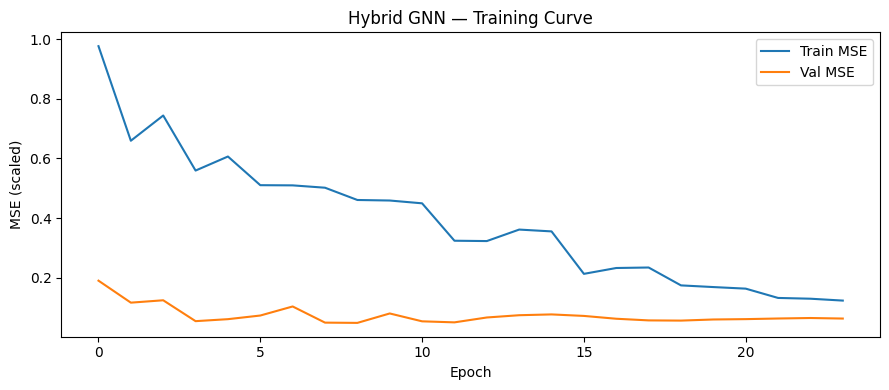

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
plt.plot(history['train'], label='Train MSE')
plt.plot(history['val'],   label='Val MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE (scaled)')
plt.title('Hybrid GNN — Training Curve')
plt.legend()
plt.tight_layout()
plt.savefig('training_curve.png', dpi=150)
plt.show()

## 7. 테스트 평가

In [81]:
# Best 모델 로드
model_hybrid.load_state_dict(
    torch.load('best_hybrid_model.pt', map_location=DEVICE)
)

# ── Persistence Baseline (단순 이전 관측값 반복) ──
def persistence_mse(dataset):
    total, count = 0.0, 0
    for x_seq, y_true, _ in dataset:
        # outlet(index=-1), 마지막 타임스텝, chl(index=5)
        y_hat = x_seq[-1, -1, 5].item()
        total += (y_true.item() - y_hat) ** 2
        count += 1
    return total / count

persist_mse = persistence_mse(test_ds)

# ── Hybrid GNN 테스트 ──────────────────────────
test_mse_hybrid = evaluate(model_hybrid, test_loader, criterion, edge_index)

# ── Transformer Baseline 테스트 ───────────────
optimizer_base = torch.optim.Adam(model_baseline.parameters(), lr=LR)
# (baseline 학습은 동일한 루프로 진행하거나 따로 셀 추가)
# test_mse_base = evaluate(model_baseline, test_loader, criterion)

print('=' * 40)
print(f'Persistence Baseline  MSE : {persist_mse:.4f}')
print(f'Hybrid GNN (Test)     MSE : {test_mse_hybrid:.4f}')
print('=' * 40)

Persistence Baseline  MSE : 0.9674
Hybrid GNN (Test)     MSE : 0.5233


 Test R² Score : -0.1078



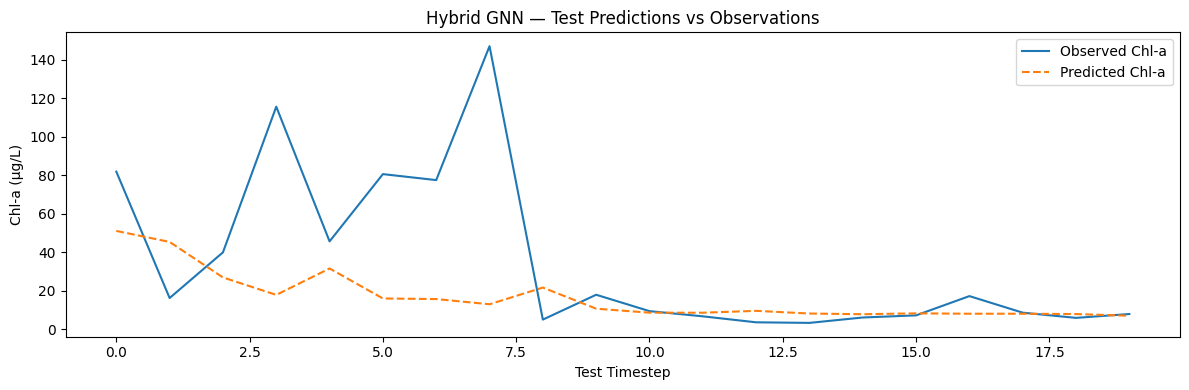

In [82]:
# 예측값 vs 실제값 시각화
import numpy as np

all_preds, all_true = [], []
model_hybrid.eval()
with torch.no_grad():
    for x_batch, y_batch, _ in test_loader:
        x_batch = x_batch.to(DEVICE)
        preds = model_hybrid(x_batch, edge_index, outlet_node_idx=OUTLET_IDX)
        all_preds.append(preds.cpu().numpy())
        all_true.append(y_batch.numpy())

all_preds = np.concatenate(all_preds, axis=0)   # [N_test, 1]
all_true  = np.concatenate(all_true,  axis=0)   # [N_test, 1]

# inverse_transform (chl만 복원)
# scaler_out은 10채널 전체에 맞춰져 있으므로 dummy 채널과 함께 복원
def inverse_chl(scaled_vals, scaler, chl_idx=5):
    dummy = np.zeros((len(scaled_vals), 10), dtype=np.float32)
    dummy[:, chl_idx] = scaled_vals.ravel()
    restored = scaler.inverse_transform(dummy)
    return restored[:, chl_idx]

preds_orig = inverse_chl(all_preds, scaler_out)
true_orig  = inverse_chl(all_true,  scaler_out)

from sklearn.metrics import r2_score
r2_val = r2_score(true_orig, preds_orig)
print(f'========================================')
print(f' Test R² Score : {r2_val:.4f}')
print(f'========================================\n')
plt.figure(figsize=(12, 4))
plt.plot(true_orig,  label='Observed Chl-a',  linewidth=1.5)
plt.plot(preds_orig, label='Predicted Chl-a', linewidth=1.5, linestyle='--')
plt.xlabel('Test Timestep')
plt.ylabel('Chl-a (μg/L)')
plt.title('Hybrid GNN — Test Predictions vs Observations')
plt.legend()
plt.tight_layout()
plt.savefig('test_predictions.png', dpi=150)
plt.show()